# Simulación de un PID de forma iterativa

### Librerías necesarias

In [1]:
from pidfunc import simula, sim_control, dibuja

El Proceso a controlar viene descrito por el siguiente modelo discreto obtenido a un período de muestreo, T = 0.1 seg.

$$G_p(z)=\frac{0.007(z+0.94)}{(z-0.95)(z-0.86)}$$

Primero simularemos el comportamiento del proceso sin regulador en lazo cerrado

Expresamos dicha función de transferencia en la ecuación en diferencias equivalente:

$$y(k)=1.81y(k-1)-0.817y(k-2)+0.007u(k-1)+0.0066u(k-2)$$

Definimos las variables que van a almacenar los datos de la simulación así como otros parámetros:

In [2]:
tsim = 15                  # Tiempo de simulación en segundos
T = 0.1                     # Período de muestreo
numiter = int(tsim/T)-2     # Número de iteraciones para la simulación
u = 1                       # Entrada escalón unitario
entrada = []
error = []
errorc = []
accont = []
salida = []
salcont = []

La función 'simula()' obtiene los valores de la simulación para instantes después del retardo

Calculamos previamente los dos primeros valores ya que provocarían índices negativos en el bucle al calcular y(k):

In [3]:
# Iteración k = 0
ek = 0
yk = 0
entrada.append(u)
error.append(ek)
salida.append(yk)

# Iteración k = 1
ek1 = u - yk
yk1 = (1.81*yk)+(0.007*ek1)
entrada.append(u)
error.append(ek1)
salida.append(yk1)

# Iteración k = 2
ek2 = u - yk1
yk2 = (1.81*yk1)-(0.817*yk)+(0.007*ek2)+(0.0066*ek1)
entrada.append(u)
error.append(ek2)
salida.append(yk2)

# Resto de iteraciones
ym1 = yk2
ym2 = yk1
em1 = ek2
em2 = ek1

simula(ym1, ym2, em1, em2)


Realizamos la obtención del resto de valores mediante un bucle:

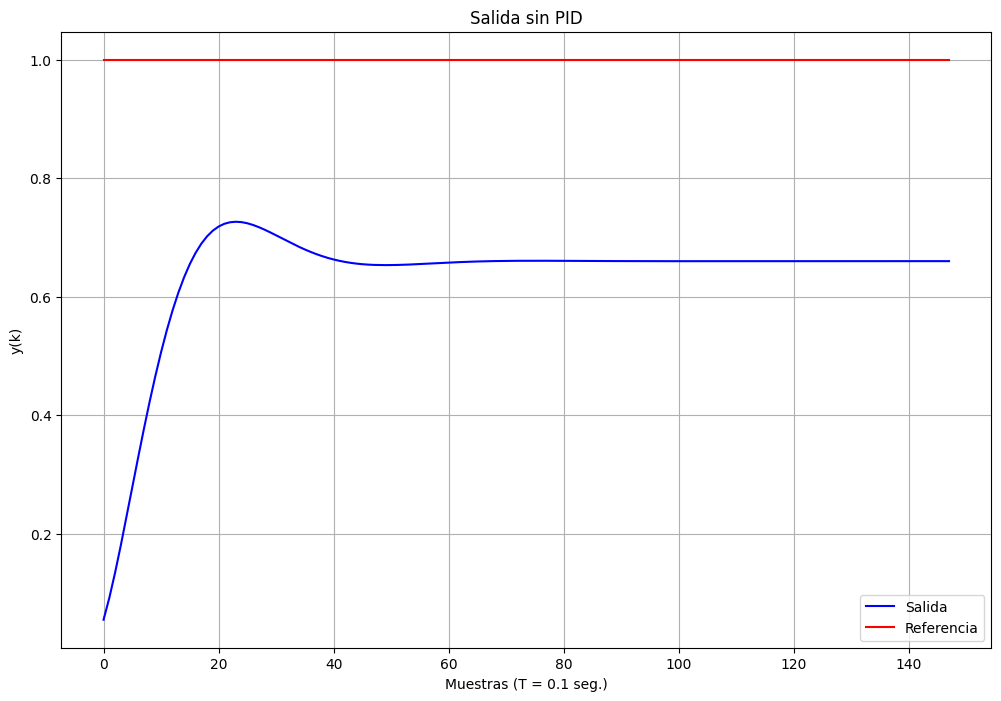

In [4]:
dibuja(1) 


Procedemos ahora a simular el sistema controlado con el regulador PID calculado:

$$G_R(z)=18.86\frac{(z-0.967)(z-0.7)}{z(z-1)}

Expresamos la salida del regulador (acción de control) mediante su correspondiente ecuación en diferencias:

$$u(k)=u(k-1)+18.86e(k)-31.4396e(k-1)+12.7663e(k-2)$$

Calculamos de nuevo los dos primeros valores de la simulación para evitar índices negativos en el bucle principal de cálculo de la salida:

In [ ]:
# Iteración k = 0
u = 1       # Entrada escalón unitario
ek = 0
ac = 0
yk = 0
#entrada.append(u)
errorc.append(ek)
accont.append(ac)
salcont.append(yk)

# Iteración k = 1
ek1 = u - yk
ac1 = 18.86*ek1
yk1 = (1.81*yk)+(0.007*ac1)
#entrada.append(u)
errorc.append(ek1)
accont.append(ac1)
salcont.append(yk1)

# Iteración k = 2
ek2 = u - yk1
ac2 = ac1+(18.86*ek2)-(31.4396*ek1)+(12.7663*ek)
yk2 = (1.81*yk1)-(0.817*yk)+(0.007*ac2)+(0.0066*ac1)
#entrada.append(u)
errorc.append(ek2)
accont.append(ac2)
salcont.append(yk2)

ym1 = yk2
ym2 = yk1
em1 = ek2
em2 = ek1
acm1 = ac2
acm2 = ac1
ec = ek2

sim_control(ym1, ym2, em1, em2, acm1, acm2, ec)

print(f'Sobreoscilación máxima: ', max(salcont))



Sobreoscilación máxima:  0.3899657196


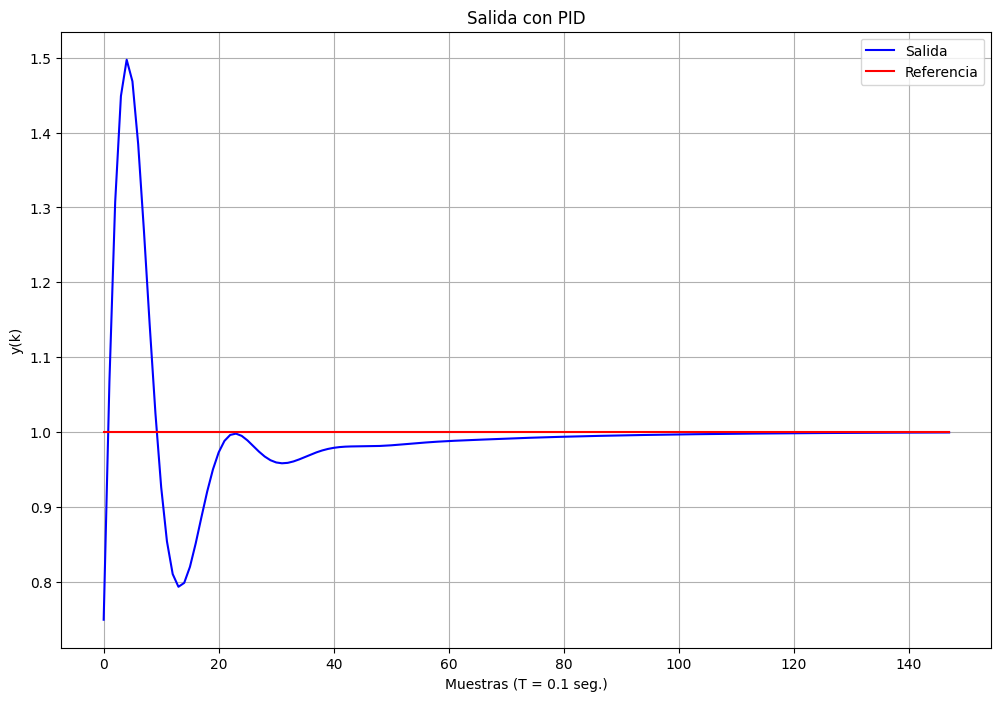

In [6]:
dibuja(2)


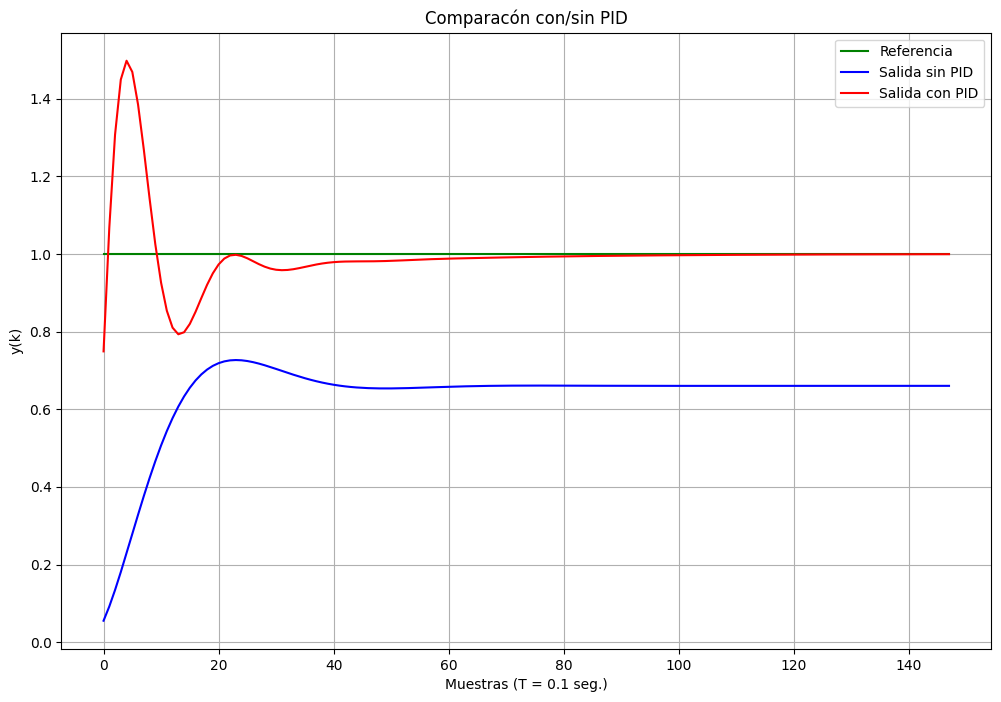

In [7]:
dibuja(3)